# TransLuxPop / CivitasGrid-TLP：Multi-Baselines (w/ Contrastive Loss)

这份 Notebook 在你之前的版本基础上做了“结构尽量不动”的改造：

- ✅ **删掉 XGB 的两组**（不再包含任何 XGB/GBDT）
- ✅ **取消所有 cross-domain 测评**（不再做 Leave-One-Group-Out）
- ✅ 增加 6 个 baseline：**Ridge Regression、Elastic Net、SVR、Random Forest Regressor、Extra Trees Regressor、MLP**
- ✅ 每个 baseline 都做 **三组**：
  - `(Baseline)`：标准 RMSE/MSE 训练
  - `(Baseline)_CL`：只用论文里的对比式损失训练“可微校准层”（不改 base 模型超参）
  - `(Baseline)_RMSE_CL`：混合训练（0.6 * RMSE_norm + 0.4 * CL_norm）

对比学习仍采用你指定的公式（batch 内 negatives）：

\[
 p_i = 

rac{\exp\left(-|\hat y_i - y_i|/T
ight)}{\sum_{j\in \mathcal{B}} \exp\left(-|\hat y_i - y_j|/T
ight)}
\]
\[
 \mathcal{L}_{con} = 

rac{1}{|\mathcal{B}|} \sum_{i\in\mathcal{B}} -\log p_i
\]

评估：保留 **Random(70/15/15)** + **GroupSplit(grid_id)**（若 grid_id 可用），并继续输出 All/Tail/Worst-case errors，保证可横向比较。


In [1]:
# 导入依赖 + 固定随机种子（可复现）
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

print('Versions:')
import sklearn
print('  pandas:', pd.__version__)
print('  numpy:', np.__version__)
print('  sklearn:', sklearn.__version__)


Versions:
  pandas: 2.3.3
  numpy: 2.3.5
  sklearn: 1.8.0


In [2]:
# 读取并初步检查 CivitasGrid-TLP / TransLuxPop（HQ）数据

data_path = 'grids_set_4_HQ.xlsx'
if not os.path.exists(data_path):
    alt = '/mnt/data/grids_set_4_HQ.xlsx'
    if os.path.exists(alt):
        data_path = alt

assert os.path.exists(data_path), f'找不到数据文件：{data_path}（请确认已上传）'

df = pd.read_excel(data_path)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('Has grid_id/year:', {'grid_id','year'}.issubset(df.columns))
print('Targets exist:', {'dVIIRS','dWorldPop'}.issubset(df.columns))

display(df.head(3))

# 为避免部分树模型在重复值上出现不稳定的分裂（可选），对 _use 与 last_year 特征加入极小扰动
use_cols = [c for c in df.columns if c.endswith('_use')] + ["VIIRS_last_year", "WorldPop_last_year"]
use_cols = [c for c in use_cols if c in df.columns]
if len(use_cols) > 0:
    df[use_cols] = df[use_cols] + np.random.uniform(-0.01, 0.01, size=df[use_cols].shape)
    print('Applied tiny jitter to:', use_cols[:6], '...')


Shape: (28330, 37)
Has grid_id/year: True
Targets exist: True


,grid_id,year,nation_code,lat_min,lon_min,lat_max,lon_max,cell_area,region_type,city_type,...,City,description,Intersec_use,mot_use,tru_use,pri_use,sec_use,ter_use,urb_use,len_unc
0,1000,2015.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,...,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0
1,1000,2016.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,...,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0
2,1000,2017.0,USA,37.556543,-77.420981,37.572814,-77.40471,2.596018,commercial,developing,...,Richmond,发展中城市：市中心商业核心，路网密集/夜光强。,108.242695,2.599565,0.850466,0.047647,1.75934,0.545176,5.066507,0


Applied tiny jitter to: ['Intersec_use', 'mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use'] ...


In [3]:
# 构造 covid_intensity 特征，并定义特征/目标列

covid_map = {
    2015: 0.0,
    2016: 0.0,
    2017: 0.0,
    2018: 0.0,
    2019: 0.05,
    2020: 0.8,
    2021: 1.0,
    2022: 0.6,
    2023: 0.4,
    2024: 0.2,
}

# year 极少缺失：无法构造 covid_intensity → 丢弃（可复现）
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)
df['covid_intensity'] = df['year'].map(covid_map).fillna(0.0)

feature_cols = [
    'mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use', 'urb_use',
    'VIIRS_last_year', 'WorldPop_last_year', 'covid_intensity',
    'region_type', 'city_type'
]

target_cols = ['dVIIRS', 'dWorldPop']

missing_cols = [c for c in feature_cols + target_cols + ['grid_id','year'] if c not in df.columns]
assert len(missing_cols) == 0, f'缺少列：{missing_cols}'

print('Feature cols:', feature_cols)
print('Targets:', target_cols)
print('Unique region_type:', df['region_type'].nunique(), 'Unique city_type:', df['city_type'].nunique())


Feature cols: ['mot_use', 'tru_use', 'pri_use', 'sec_use', 'ter_use', 'urb_use', 'VIIRS_last_year', 'WorldPop_last_year', 'covid_intensity', 'region_type', 'city_type']
Targets: ['dVIIRS', 'dWorldPop']
Unique region_type: 5 Unique city_type: 5


In [4]:
# 缺失值处理策略与缺失概况
# - 数值特征：中位数填补（仅在训练集 fit，防泄漏）
# - 类别特征：缺失填 'Unknown'（仅在训练集 fit，防泄漏）
# - 目标 y：建模时必须非缺失（每个目标分别过滤）

numeric_cols = [
    'mot_use','tru_use','pri_use','sec_use','ter_use','urb_use',
    'VIIRS_last_year','WorldPop_last_year','covid_intensity'
]

categorical_cols = ['region_type','city_type']

missing_summary = df[feature_cols + target_cols].isna().mean().sort_values(ascending=False)
display(missing_summary.to_frame('missing_ratio').head(12))


,missing_ratio
VIIRS_last_year,0.100004
dWorldPop,0.100004
dVIIRS,0.100004
WorldPop_last_year,0.100004
mot_use,0.000000
ter_use,0.000000
sec_use,0.000000
pri_use,0.000000
tru_use,0.000000
covid_intensity,0.000000


In [5]:
# 定义预处理器（数值缺失填补 + 标准化 + 类别 One-Hot）

def build_preprocessor(numeric_features: List[str], categorical_features: List[str]) -> ColumnTransformer:
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    numeric_tf = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_tf = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', ohe)
    ])

    pre = ColumnTransformer(
        transformers=[
            ('num', numeric_tf, numeric_features),
            ('cat', categorical_tf, categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )
    return pre

preprocessor = build_preprocessor(numeric_cols, categorical_cols)


In [6]:
# Contrastive Learning 目标函数 + 混合训练（RMSE + CL）+ 指标

# -------------------------
# Contrastive config knobs
# -------------------------
CL_BATCH_SIZE = 128
CL_EPOCHS = 40
CL_LR = 0.05
CL_TEMP_FACTOR = 1.0
CL_EPS = 1e-12


def compute_temperature(y_train: np.ndarray, factor: float = CL_TEMP_FACTOR) -> float:
    s = float(np.std(y_train))
    return max(s * float(factor), 1e-3)


def contrastive_loss_and_p(y_pred: np.ndarray, y_true: np.ndarray, T: float):
    # batch 内全对比：negatives = batch 中其它 y_j
    # p_i = exp(-|yhat_i - y_i|/T) / sum_j exp(-|yhat_i - y_j|/T)
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    B = len(y_true)
    if B == 0:
        return np.nan, np.array([])
    T = float(max(T, 1e-6))

    D = np.abs(y_pred[:, None] - y_true[None, :])  # (B,B)
    logits = -D / T
    # 稳定 softmax
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    denom = np.sum(exp_logits, axis=1)
    numer = np.diag(exp_logits)
    p = numer / np.maximum(denom, CL_EPS)
    loss = float(np.mean(-np.log(np.maximum(p, CL_EPS))))
    return loss, p


def contrastive_grad_yhat(y_pred: np.ndarray, y_true: np.ndarray, T: float) -> np.ndarray:
    # 计算 dL_con / d y_pred（batch 全对比，L1 距离）
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    B = len(y_true)
    if B == 0:
        return np.array([])
    T = float(max(T, 1e-6))

    D = np.abs(y_pred[:, None] - y_true[None, :])
    logits = -D / T
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    denom = np.sum(exp_logits, axis=1, keepdims=True)
    P = exp_logits / np.maximum(denom, CL_EPS)  # row softmax

    # sign matrix s_ij = sign(yhat_i - y_j)
    S = np.sign(y_pred[:, None] - y_true[None, :])
    S_diag = np.diag(S)

    # grad_i = (1/T) * ( s_ii - sum_j P_ij * s_ij )
    grad = (S_diag - np.sum(P * S, axis=1)) / T
    grad = grad / float(B)  # mean over batch
    return grad


def rmse_loss_and_grad_yhat(y_pred: np.ndarray, y_true: np.ndarray) -> tuple:
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    B = len(y_true)
    if B == 0:
        return np.nan, np.array([])
    err = y_pred - y_true
    mse = float(np.mean(err * err))
    rmse = float(np.sqrt(max(mse, 0.0)))
    denom = max(rmse, 1e-6)
    grad = (err / denom) / float(B)
    return rmse, grad


@dataclass
class CalibResult:
    a: float
    b: float
    logs: Dict[str, List[float]]


def train_affine_calibrator(
    yhat_base: np.ndarray,
    y_true: np.ndarray,
    T: float,
    mode: str = 'cl',
    rmse_weight: float = 0.6,
    cl_weight: float = 0.4,
    epochs: int = CL_EPOCHS,
    batch_size: int = CL_BATCH_SIZE,
    lr: float = CL_LR,
    seed: int = SEED,
    rmse0: float = None,
    cl0: float = None,
) -> CalibResult:
    """
    训练一个非常轻量的可微校准层： y' = a*yhat + b
    - (Baseline)_CL：优化 L_con
    - (Baseline)_RMSE_CL：优化 0.6*RMSE_norm + 0.4*CL_norm

    ✅ 改动：
    1) cl0（baseline contrastive loss 用于归一化）改成子采样估计，避免全量 O(N^2) 爆炸。
    2) 增加 flush 的心跳输出，方便判断是否“活着”。
    """

    import sys
    import time
    import numpy as np

    t_start = time.time()
    rng = np.random.default_rng(seed)
    yhat_base = np.asarray(yhat_base, dtype=float)
    y_true = np.asarray(y_true, dtype=float)

    n = len(y_true)
    if n == 0:
        return CalibResult(a=1.0, b=0.0, logs={'loss': [], 'rmse': [], 'cl': []})

    # -----------------------------
    # ✅ 关键：CL 的 O(N^2) 防爆策略
    # -----------------------------
    # 这些阈值你可以按机器能力调：
    # - 太大：容易慢/爆内存
    # - 太小：cl0 估计噪声大，但通常也够用了（反正是归一化基准）
    CL0_MAX_N = 3000          # 用于估计 cl0 的最大样本数
    CL0_BATCH = 512           # cl0 用的小 batch（避免 contrastive 里构造大矩阵）
    CL_EVAL_MAX_N = 3000      # epoch end 记录 cl_full 时同样子采样，避免日志阶段卡死

    def _subsample(x: np.ndarray, y: np.ndarray, max_n: int):
        if len(y) <= max_n:
            return x, y
        idx = rng.choice(len(y), size=max_n, replace=False)
        return x[idx], y[idx]

    def _estimate_cl_mean(x: np.ndarray, y: np.ndarray, T: float, bs: int) -> float:
        """
        用小 batch 平均来估计 contrastive loss，避免一次性对全量做 O(N^2)。
        注意：这是“估计”，不是严格等价全量 loss，但用来当归一化标尺非常够用。
        """
        n_local = len(y)
        if n_local == 0:
            return 0.0
        perm = rng.permutation(n_local)
        vals = []
        for s in range(0, n_local, bs):
            bidx = perm[s:s + bs]
            # 这里调用你原来的 contrastive loss（假设它在 batch 内部可算）
            cl_val, _ = contrastive_loss_and_p(x[bidx], y[bidx], T)
            vals.append(float(cl_val))
        return float(np.mean(vals)) if len(vals) else 0.0

    # -----------------------------
    # 参数初始化
    # -----------------------------
    a, b = 1.0, 0.0

    # baseline rmse 用于归一化（这一步是 O(N) 安全的）
    if rmse0 is None:
        rmse0, _ = rmse_loss_and_grad_yhat(a * yhat_base + b, y_true)
        rmse0 = float(max(rmse0, 1e-6))
    else:
        rmse0 = float(max(float(rmse0), 1e-6))

    # ✅ baseline cl 用于归一化：子采样 + 小 batch 估计，防止全量 O(N^2)
    if cl0 is None:
        if mode in ('cl', 'rmse_cl'):
            xb0, yb0 = _subsample(yhat_base, y_true, CL0_MAX_N)
            cl0 = _estimate_cl_mean(a * xb0 + b, yb0, T, CL0_BATCH)
            cl0 = float(max(cl0, 1e-6))
        else:
            cl0 = 1.0  # 理论上不会走到这，因为 mode 会校验
    else:
        cl0 = float(max(float(cl0), 1e-6))

    print(
        f"[calib] mode={mode} n={n} epochs={int(epochs)} batch={int(batch_size)} lr={lr} "
        f"| rmse0={rmse0:.6f} cl0≈{cl0:.6f} (subsampled)",
        flush=True
    )
    sys.stdout.flush()

    # Adam
    m_a = v_a = 0.0
    m_b = v_b = 0.0
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8

    logs = {'loss': [], 'rmse': [], 'cl': []}

    # 心跳频率：每多少 step 打印一次（你可以调小让输出更多）
    HEARTBEAT_EVERY = 50

    step = 0
    for ep in range(int(epochs)):
        idx = rng.permutation(n)
        ep_loss_acc = 0.0
        ep_rmse_acc = 0.0
        ep_cl_acc = 0.0
        nb = 0

        for start in range(0, n, int(batch_size)):
            step += 1
            batch = idx[start:start + int(batch_size)]
            yb = y_true[batch]
            xb = yhat_base[batch]

            yhat = a * xb + b

            # losses + grads wrt yhat
            rmse, grad_rmse = rmse_loss_and_grad_yhat(yhat, yb)
            cl, _ = contrastive_loss_and_p(yhat, yb, T)
            grad_cl = contrastive_grad_yhat(yhat, yb, T)

            if mode == 'cl':
                loss = cl
                grad_yhat = grad_cl
            elif mode == 'rmse_cl':
                rmse_norm = rmse / rmse0
                cl_norm = cl / cl0
                loss = rmse_weight * rmse_norm + cl_weight * cl_norm
                grad_yhat = rmse_weight * (grad_rmse / rmse0) + cl_weight * (grad_cl / cl0)
            else:
                raise ValueError('mode must be cl or rmse_cl')

            # chain rule to a,b
            g_a = float(np.sum(grad_yhat * xb))
            g_b = float(np.sum(grad_yhat))

            # Adam update
            m_a = beta1 * m_a + (1 - beta1) * g_a
            v_a = beta2 * v_a + (1 - beta2) * (g_a * g_a)
            m_b = beta1 * m_b + (1 - beta1) * g_b
            v_b = beta2 * v_b + (1 - beta2) * (g_b * g_b)

            m_a_hat = m_a / (1 - beta1 ** step)
            v_a_hat = v_a / (1 - beta2 ** step)
            m_b_hat = m_b / (1 - beta1 ** step)
            v_b_hat = v_b / (1 - beta2 ** step)

            a -= lr * m_a_hat / (np.sqrt(v_a_hat) + eps)
            b -= lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

            # 记录 batch 统计（用于更“活着”的输出）
            ep_loss_acc += float(loss)
            ep_rmse_acc += float(rmse)
            ep_cl_acc += float(cl)
            nb += 1

            if (step % HEARTBEAT_EVERY) == 0:
                avg_loss = ep_loss_acc / max(nb, 1)
                avg_rmse = ep_rmse_acc / max(nb, 1)
                avg_cl = ep_cl_acc / max(nb, 1)
                print(
                    f"[calib] ep={ep+1}/{int(epochs)} step={step} "
                    f"| loss≈{avg_loss:.6f} rmse≈{avg_rmse:.6f} cl≈{avg_cl:.6f} "
                    f"| a={a:.5f} b={b:.5f} | {time.time()-t_start:.1f}s",
                    flush=True
                )
                sys.stdout.flush()

        # -----------------------------
        # epoch end logging（⚠️ 原版这里会全量算 cl_full -> 可能又 O(N^2) 卡死）
        # 改成：rmse 全量（安全） + cl 子采样估计（安全）
        # -----------------------------
        yhat_full = a * yhat_base + b
        rmse_full, _ = rmse_loss_and_grad_yhat(yhat_full, y_true)

        # cl_full 只用子采样估计
        xbe, ybe = _subsample(yhat_full, y_true, CL_EVAL_MAX_N)
        cl_full = _estimate_cl_mean(xbe, ybe, T, CL0_BATCH)

        if mode == 'rmse_cl':
            loss_full = rmse_weight * (rmse_full / rmse0) + cl_weight * (cl_full / cl0)
        else:
            loss_full = cl_full

        logs['loss'].append(float(loss_full))
        logs['rmse'].append(float(rmse_full))
        logs['cl'].append(float(cl_full))

        print(
            f"[calib] ✅ epoch_end ep={ep+1}/{int(epochs)} "
            f"| loss={loss_full:.6f} rmse={float(rmse_full):.6f} cl≈{float(cl_full):.6f} "
            f"| a={a:.5f} b={b:.5f} | {time.time()-t_start:.1f}s",
            flush=True
        )
        sys.stdout.flush()

    logs['rmse0'] = float(rmse0)
    logs['cl0'] = float(cl0)
    return CalibResult(a=float(a), b=float(b), logs=logs)


def compute_tail_thresholds(y_train: np.ndarray, q_low: float = 0.05, q_high: float = 0.95) -> Tuple[float, float]:
    q05 = np.quantile(y_train, q_low)
    q95 = np.quantile(y_train, q_high)
    return float(q05), float(q95)


def tail_mask(y: np.ndarray, q05: float, q95: float) -> np.ndarray:
    y = np.asarray(y)
    return (y <= q05) | (y >= q95)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    abs_err = np.abs(y_true - y_pred)
    return {
        'MAE': float(mae),
        'RMSE': float(rmse),
        'R2': float(r2),
        'AbsErr_P95': float(np.quantile(abs_err, 0.95)),
        'AbsErr_P99': float(np.quantile(abs_err, 0.99)),
    }


def evaluate_with_tail(y_true: np.ndarray, y_pred: np.ndarray, q05: float, q95: float) -> Dict[str, float]:
    out = {}
    out.update({f'All_{k}': v for k, v in regression_metrics(y_true, y_pred).items()})
    m = tail_mask(y_true, q05, q95)
    out['Tail_Rate'] = float(m.mean())
    if m.sum() > 0:
        out.update({f'Tail_{k}': v for k, v in regression_metrics(y_true[m], y_pred[m]).items()})
    else:
        out.update({f'Tail_{k}': np.nan for k in ['MAE','RMSE','R2','AbsErr_P95','AbsErr_P99']})
    return out


In [7]:
# 定义 Baseline 模型与超参（显式写出，便于复现）

BASELINES = {
    'Ridge': dict(alpha=1.0),
    'ElasticNet': dict(alpha=1.0, l1_ratio=0.5, max_iter=5000, random_state=SEED),
    'SVR': dict(C=10.0, epsilon=0.1, kernel='rbf'),
    'RandomForest': dict(n_estimators=150, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=SEED, n_jobs=-1),
    'ExtraTrees': dict(n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=SEED, n_jobs=-1),
    'MLP': dict(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', alpha=1e-4, max_iter=400, random_state=SEED, verbose=True, early_stopping=True, validation_fraction=0.1, n_iter_no_change=15),
}

def build_model(name: str):
    cfg = BASELINES[name]
    if name == 'Ridge':
        return Ridge(**cfg)
    if name == 'ElasticNet':
        return ElasticNet(**cfg)
    if name == 'SVR':
        return SVR(**cfg)
    if name == 'RandomForest':
        return RandomForestRegressor(**cfg)
    if name == 'ExtraTrees':
        return ExtraTreesRegressor(**cfg)
    if name == 'MLP':
        return MLPRegressor(**cfg)
    raise KeyError(name)

BASELINE_NAMES = list(BASELINES.keys())
print('Baselines:', BASELINE_NAMES)


Baselines: ['Ridge', 'ElasticNet', 'SVR', 'RandomForest', 'ExtraTrees', 'MLP']


In [8]:
# 数据切分：Random / GroupSplit(grid_id)

def make_random_split(df_in: pd.DataFrame, test_size=0.15, val_size=0.15, seed=SEED):
    idx = np.arange(len(df_in))
    train_idx, temp_idx = train_test_split(idx, test_size=test_size+val_size, random_state=seed, shuffle=True)
    rel_test = test_size / (test_size + val_size)
    val_idx, test_idx = train_test_split(temp_idx, test_size=rel_test, random_state=seed, shuffle=True)
    return train_idx, val_idx, test_idx


def make_group_split_by_grid(df_in: pd.DataFrame, group_col='grid_id', test_size=0.15, val_size=0.15, seed=SEED):
    groups = df_in[group_col].astype(str).values

    # 先划 test
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(gss.split(np.arange(len(df_in)), groups=groups))

    # 再从 train_val 中划 val
    groups_tv = groups[train_val_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size/(1.0 - test_size), random_state=seed)
    train_idx_rel, val_idx_rel = next(gss2.split(train_val_idx, groups=groups_tv))
    train_idx = train_val_idx[train_idx_rel]
    val_idx = train_val_idx[val_idx_rel]

    return train_idx, val_idx, test_idx


In [9]:
import time
# 训练与推理：每个 baseline -> 3 组（Base / _CL / _RMSE_CL）

@dataclass
class FitArtifacts:
    y_true: np.ndarray
    y_pred: np.ndarray
    tail_q05: float
    tail_q95: float
    diag_test: Optional[np.ndarray] = None
    diag_name: Optional[str] = None
    extra: Optional[dict] = None


def build_pipeline(model_name: str) -> Pipeline:
    model = build_model(model_name)
    pipe = Pipeline(steps=[
        ('pre', preprocessor),
        ('model', model)
    ])
    return pipe


def _filter_nonmissing(df_in: pd.DataFrame, idx: np.ndarray, target: str) -> np.ndarray:
    sub = df_in.iloc[idx]
    m = sub[target].notna().values
    return idx[m]


def _approx_test_diag_p(y_pred: np.ndarray, y_true: np.ndarray, T: float, batch_size: int = 256, seed: int = SEED) -> np.ndarray:
    # 诊断用：在 test 上用随机 mini-batch 计算 p_i（避免 O(n^2) 全量）
    rng = np.random.default_rng(seed)
    n = len(y_true)
    if n == 0:
        return np.array([])
    order = rng.permutation(n)
    ps = []
    for start in range(0, n, batch_size):
        b = order[start:start+batch_size]
        _, p = contrastive_loss_and_p(y_pred[b], y_true[b], T)
        ps.append(p)
    return np.concatenate(ps, axis=0)


def fit_one_model_three_variants(
    df_in: pd.DataFrame,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    target: str,
    baseline_name: str,
) -> Tuple[List[dict], Dict[str, FitArtifacts]]:

    # 1) target 过滤（每个 target 分开过滤，避免 y 缺失带来的不一致）
    tr = _filter_nonmissing(df_in, train_idx, target)
    va = _filter_nonmissing(df_in, val_idx, target)
    te = _filter_nonmissing(df_in, test_idx, target)

    X_tr = df_in.iloc[tr][feature_cols]
    y_tr = df_in.iloc[tr][target].astype(float).values
    X_va = df_in.iloc[va][feature_cols]
    y_va = df_in.iloc[va][target].astype(float).values
    X_te = df_in.iloc[te][feature_cols]
    y_te = df_in.iloc[te][target].astype(float).values

    # tail 阈值只用 train 算
    q05, q95 = compute_tail_thresholds(y_tr, 0.05, 0.95)

    # 2) baseline fit（RMSE/MSE）
    pipe = build_pipeline(baseline_name)
    t0 = time.time()
    print(f"🚀 Fitting {baseline_name} on target={target} | n_tr={len(y_tr)}")
    pipe.fit(X_tr, y_tr)
    dt = time.time() - t0
    try:
        n_iter = getattr(pipe.named_steps['model'], 'n_iter_', None)
    except Exception:
        n_iter = None
    print(f"✅ Done {baseline_name} | {dt:.1f}s | n_iter={n_iter}")

    yhat_tr = pipe.predict(X_tr)
    yhat_te = pipe.predict(X_te)

    # 温度（按 train 自适应）
    T = compute_temperature(y_tr, CL_TEMP_FACTOR)

    rows = []
    arts = {}

    # ---- Variant A: Baseline ----
    m = evaluate_with_tail(y_te, yhat_te, q05, q95)
    row = {'Target': target, 'Model': baseline_name}
    row.update(m)
    rows.append(row)
    arts[baseline_name] = FitArtifacts(y_true=y_te, y_pred=yhat_te, tail_q05=q05, tail_q95=q95)

    # ---- Variant B: (Baseline)_CL ----
    calib_cl = train_affine_calibrator(yhat_tr, y_tr, T=T, mode='cl')
    yhat_te_cl = calib_cl.a * yhat_te + calib_cl.b

    m = evaluate_with_tail(y_te, yhat_te_cl, q05, q95)
    name_cl = f'{baseline_name}_CL'
    row = {'Target': target, 'Model': name_cl}
    row.update(m)
    rows.append(row)

    diag_p = _approx_test_diag_p(yhat_te_cl, y_te, T=T, batch_size=256, seed=SEED)
    arts[name_cl] = FitArtifacts(
        y_true=y_te,
        y_pred=yhat_te_cl,
        tail_q05=q05,
        tail_q95=q95,
        diag_test=diag_p,
        diag_name='p_i',
        extra={'T': T, 'calib': calib_cl}
    )

    # ---- Variant C: (Baseline)_RMSE_CL ----
    calib_mix = train_affine_calibrator(yhat_tr, y_tr, T=T, mode='rmse_cl', rmse_weight=0.6, cl_weight=0.4)
    yhat_te_mix = calib_mix.a * yhat_te + calib_mix.b

    m = evaluate_with_tail(y_te, yhat_te_mix, q05, q95)
    name_mix = f'{baseline_name}_RMSE_CL'
    row = {'Target': target, 'Model': name_mix}
    row.update(m)
    rows.append(row)

    diag_p2 = _approx_test_diag_p(yhat_te_mix, y_te, T=T, batch_size=256, seed=SEED)
    arts[name_mix] = FitArtifacts(
        y_true=y_te,
        y_pred=yhat_te_mix,
        tail_q05=q05,
        tail_q95=q95,
        diag_test=diag_p2,
        diag_name='p_i',
        extra={'T': T, 'calib': calib_mix}
    )

    return rows, arts


def run_all_models_on_split(df_in, train_idx, val_idx, test_idx, target: str):
    rows_all = []
    arts_all = {}
    for i, bname in enumerate(BASELINE_NAMES, start=1):
        print(f"\n==================== [{i}/{len(BASELINE_NAMES)}] {bname} ====================")
        rows, arts = fit_one_model_three_variants(df_in, train_idx, val_idx, test_idx, target, bname)
        rows_all.extend(rows)
        arts_all.update(arts)
    return rows_all, arts_all


In [10]:
# Split size 打印（只统计 non-missing y）

def pretty_print_split_sizes(df_in, train_idx, val_idx, test_idx, target: str):
    n_train = df_in.iloc[train_idx][target].notna().sum()
    n_val = df_in.iloc[val_idx][target].notna().sum()
    n_test = df_in.iloc[test_idx][target].notna().sum()
    print(f'[{target}] train/val/test (non-missing y): {n_train}/{n_val}/{n_test}')


In [11]:
# 输出目录与保存工具
import os, re

OUTDIR = 'paper_figs_multibaselines'
os.makedirs(OUTDIR, exist_ok=True)


def safe(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", s)


def save_fig(fig, name: str):
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, dpi=400, bbox_inches='tight')
    plt.close(fig)
    return path

print('OUTDIR =', OUTDIR)


OUTDIR = paper_figs_multibaselines


[calib] mode=rmse_cl n=17847 epochs=1 batch=128 lr=0.05 | rmse0=41.842008 cl0≈6.157909 (subsampled)
[calib] ep=1/1 step=50 | loss≈0.894433 rmse≈40.660169 cl≈4.793627 | a=0.95152 b=-0.04612 | 0.1s
[calib] ep=1/1 step=100 | loss≈0.904580 rmse≈41.358189 cl≈4.795744 | a=0.94354 b=-0.11633 | 0.1s
[calib] ✅ epoch_end ep=1/1 | loss=1.000553 rmse=41.937187 cl≈6.145409 | a=1.08432 b=0.35835 | 0.2s
[calib] mode=rmse_cl n=17847 epochs=40 batch=128 lr=0.05 | rmse0=41.842008 cl0≈6.157909 (subsampled)
[calib] ep=1/40 step=50 | loss≈0.766445 rmse≈50.644032 cl≈4.719696 | a=2.33707 b=0.31416 | 0.1s
[calib] ep=1/40 step=100 | loss≈0.766003 rmse≈53.624346 cl≈4.716975 | a=2.29756 b=-1.14933 | 0.1s
[calib] ✅ epoch_end ep=1/40 | loss=0.984276 rmse=59.264128 cl≈6.061079 | a=2.38000 b=-1.99876 | 0.2s
[calib] ep=2/40 step=150 | loss≈0.765835 rmse≈61.589270 cl≈4.715943 | a=2.34764 b=-2.19882 | 0.2s
[calib] ep=2/40 step=200 | loss≈0.765295 rmse≈58.449996 cl≈4.712617 | a=2.49956 b=-3.02789 | 0.2s
[calib] ep=2/40 

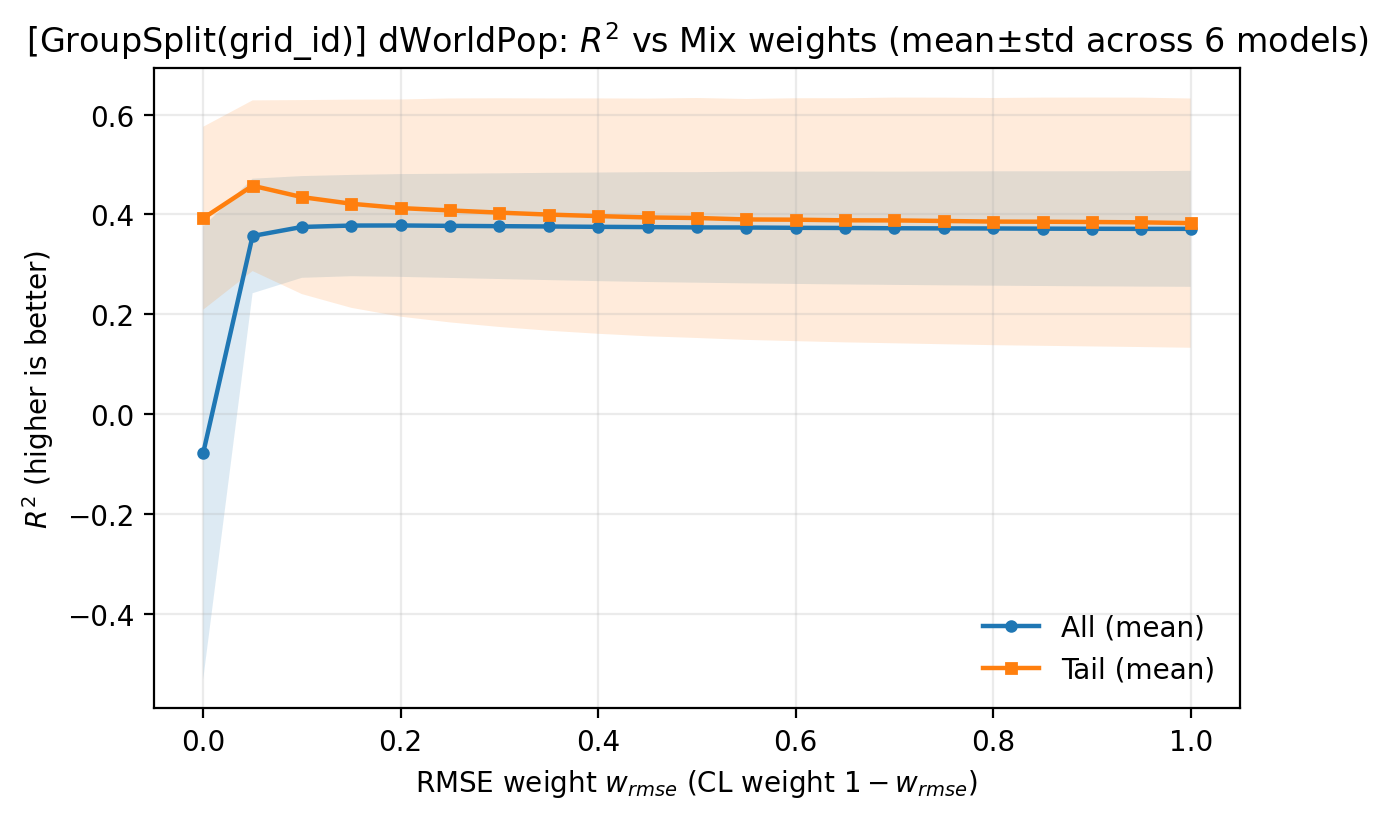

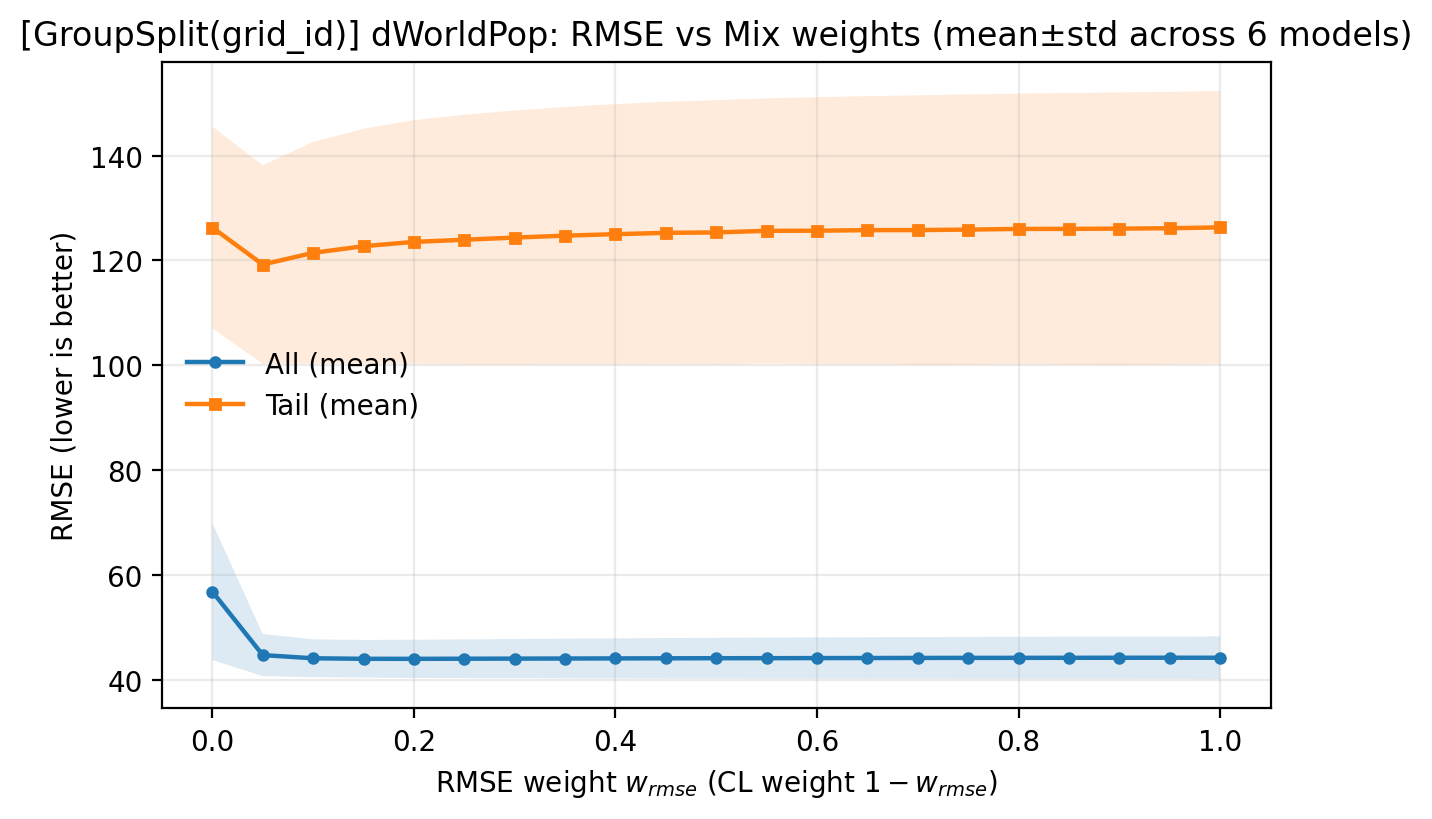

In [14]:
# ===========================
# Mix-weight sweep (RMSE vs CL) - OPTIMIZED VERSION
# ===========================
# We sweep the RMSE weight w in [0,1]. CL weight is (1-w).
# At w=1: RMSE-only. At w=0: CL-only.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Settings ----
MODEL_NAMES = ["Ridge", "ElasticNet", "SVR", "RandomForest", "ExtraTrees", "MLP"]

# Prefer existing constants if defined earlier in the notebook
_TEMP_FACTOR = float(globals().get("CL_TEMP_FACTOR", 1.0))
_SEED = int(globals().get("SEED", 42))
_OUTDIR = globals().get("OUTDIR", "outputs_mix_weight_sweep")
os.makedirs(_OUTDIR, exist_ok=True)

# Sanity checks (fail fast with a clear message)
required_globals = ["df", "feature_cols", "build_pipeline", "make_random_split", "make_group_split_by_grid",
                    "_filter_nonmissing", "train_affine_calibrator", "evaluate_with_tail", "safe"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required objects in notebook scope: {missing}. "
                    f"Run the earlier data/prep cells first.")

def _get_split_indices(split_name: str):
    """Return (idx_tr, idx_va, idx_te) over the FULL df indices (before target-specific NaN filtering)."""
    if split_name == "Random(70/15/15)":
        return make_random_split(df, seed=_SEED)
    elif split_name == "GroupSplit(grid_id)":
        return make_group_split_by_grid(df, group_col="grid_id", seed=_SEED)
    else:
        raise ValueError(f"Unknown split_name: {split_name}")

def _fit_baseline_once(model_name: str, target: str, idx_tr, idx_va, idx_te):
    """
    ✅ OPTIMIZED: Fit baseline pipeline ONCE, cache results in a dict.
    Avoids redundant preprocessing/fitting when sweeping weights.
    """
    # Target-specific non-missing filtering
    idx_tr2 = _filter_nonmissing(df, idx_tr, target)
    idx_va2 = _filter_nonmissing(df, idx_va, target)
    idx_te2 = _filter_nonmissing(df, idx_te, target)

    X_tr = df.iloc[idx_tr2][feature_cols]
    y_tr = df.iloc[idx_tr2][target].to_numpy(dtype=float)

    X_te = df.iloc[idx_te2][feature_cols]
    y_te = df.iloc[idx_te2][target].to_numpy(dtype=float)

    # Fit pipeline once
    pipe = build_pipeline(model_name)
    pipe.fit(X_tr, y_tr)

    # ✅ Pre-compute predictions (cached for all weights)
    yhat_tr = pipe.predict(X_tr).astype(float)
    yhat_te = pipe.predict(X_te).astype(float)

    # ✅ Vectorized quantile calculation
    q05, q95 = np.quantile(y_tr, [0.05, 0.95])
    T = max(float(np.std(y_tr)) * _TEMP_FACTOR, 1e-3)

    return {
        "model": model_name,
        "T": T,
        "q05": float(q05),
        "q95": float(q95),
        "y_tr": y_tr, "yhat_tr": yhat_tr,
        "y_te": y_te, "yhat_te": yhat_te,
    }

def run_mix_weight_sweep(split_name: str, target: str, weights: np.ndarray, model_names=MODEL_NAMES, verbose=True):
    """
    ✅ OPTIMIZED: 
      - Cache baseline fit once per model
      - Reuse cached predictions for each weight sweep
      - Vectorized aggregation
      - Reduced console output overhead
    """
    idx_tr, idx_va, idx_te = _get_split_indices(split_name)

    rows = []
    total_models = len(model_names)
    
    for model_idx, model_name in enumerate(model_names, start=1):
        if verbose:
            print(f"[{model_idx}/{total_models}] {model_name}: fitting baseline...", end=" ", flush=True)
        
        # ✅ Fit baseline once and cache all predictions
        base = _fit_baseline_once(model_name, target, idx_tr, idx_va, idx_te)
        
        if verbose:
            print(f"calibrating constants...", end=" ", flush=True)

        # ✅ Warm run: compute (rmse0, cl0) once for this model
        warm = train_affine_calibrator(
            yhat_base=base["yhat_tr"],
            y_true=base["y_tr"],
            T=base["T"],
            mode="rmse_cl",
            rmse_weight=0.6, cl_weight=0.4,
            epochs=1, lr=0.05, batch_size=128, seed=_SEED,
            rmse0=None, cl0=None,
        )
        rmse0 = float(warm.logs.get("rmse0", np.nan))
        cl0 = float(warm.logs.get("cl0", np.nan))
        
        if verbose:
            print(f"sweeping {len(weights)} weights", flush=True)

        # ✅ Weight sweep: reuse cached baseline predictions
        for w_idx, w_rmse in enumerate(weights):
            w_rmse = float(w_rmse)
            w_cl = float(1.0 - w_rmse)

            calib = train_affine_calibrator(
                yhat_base=base["yhat_tr"],
                y_true=base["y_tr"],
                T=base["T"],
                mode="rmse_cl",
                rmse_weight=w_rmse, cl_weight=w_cl,
                epochs=40, lr=0.05, batch_size=128, seed=_SEED,
                rmse0=rmse0, cl0=cl0,
            )

            # Apply calibration to cached test predictions
            yhat_te_cal = calib.a * base["yhat_te"] + calib.b

            m = evaluate_with_tail(
                y_true=base["y_te"],
                y_pred=yhat_te_cal,
                q05=base["q05"],
                q95=base["q95"],
            )

            rows.append({
                "split": split_name,
                "target": target,
                "model": model_name,
                "w_rmse": w_rmse,
                "w_cl": w_cl,
                "R2_all": m["All_R2"],
                "RMSE_all": m["All_RMSE"],
                "R2_tail": m["Tail_R2"],
                "RMSE_tail": m["Tail_RMSE"],
            })

    # ✅ Vectorized DataFrame creation + aggregation
    df_raw = pd.DataFrame(rows)

    df_agg = (
        df_raw.groupby(["split", "target", "w_rmse"], as_index=False)
        .agg(
            mean_R2_all=("R2_all", "mean"),
            std_R2_all=("R2_all", "std"),
            mean_R2_tail=("R2_tail", "mean"),
            std_R2_tail=("R2_tail", "std"),
            mean_RMSE_all=("RMSE_all", "mean"),
            std_RMSE_all=("RMSE_all", "std"),
            mean_RMSE_tail=("RMSE_tail", "mean"),
            std_RMSE_tail=("RMSE_tail", "std"),
        )
        .sort_values("w_rmse")
        .reset_index(drop=True)
    )

    return df_raw, df_agg

def plot_metric_sweep(df_agg: pd.DataFrame, metric: str, title: str = None, save_path: str = None):
    """
    ✅ OPTIMIZED: Vectorized plot operations.
    metric in {"R2", "RMSE"}.
    Plots mean±std across 6 models for All and Tail.
    """
    assert metric in {"R2", "RMSE"}

    # ✅ Pre-compute all values once
    x = df_agg["w_rmse"].to_numpy()
    if metric == "R2":
        y_all = df_agg["mean_R2_all"].to_numpy()
        s_all = df_agg["std_R2_all"].to_numpy()
        y_tail = df_agg["mean_R2_tail"].to_numpy()
        s_tail = df_agg["std_R2_tail"].to_numpy()
        ylabel = r"$R^2$ (higher is better)"
    else:
        y_all = df_agg["mean_RMSE_all"].to_numpy()
        s_all = df_agg["std_RMSE_all"].to_numpy()
        y_tail = df_agg["mean_RMSE_tail"].to_numpy()
        s_tail = df_agg["std_RMSE_tail"].to_numpy()
        ylabel = "RMSE (lower is better)"

    fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=200)

    ax.plot(x, y_all, marker="o", markersize=3.5, linewidth=1.6, label="All (mean)", alpha=0.8)
    ax.fill_between(x, y_all - s_all, y_all + s_all, alpha=0.12)

    ax.plot(x, y_tail, marker="s", markersize=3.5, linewidth=1.6, label="Tail (mean)", alpha=0.8)
    ax.fill_between(x, y_tail - s_tail, y_tail + s_tail, alpha=0.12)

    ax.set_xlabel("RMSE weight $w_{rmse}$ (CL weight $1-w_{rmse}$)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(frameon=False, loc="best", fontsize=10)

    if title is None:
        title = f"Mix-weight sweep: {metric}"
    ax.set_title(title, fontsize=12, fontweight='bold')

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=200)
    return fig

# ---- Run sweep ----
print("=" * 70)
print("Starting Mix-Weight Sweep (OPTIMIZED)")
print("=" * 70)

# Step: set to 0.05 (21 points). Use 0.02 if you want denser sweep (51 points).
step = 0.05
weights = np.arange(0.0, 1.0 + 1e-9, step)

# Recommended primary setting:
split_name = "GroupSplit(grid_id)"
target = "dWorldPop"

df_sweep_raw, df_sweep_agg = run_mix_weight_sweep(
    split_name=split_name, 
    target=target, 
    weights=weights,
    verbose=True
)

# Save raw + aggregated results (optional but convenient)
raw_path = os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__mix_weight_sweep__raw.csv")
agg_path = os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__mix_weight_sweep__agg.csv")
df_sweep_raw.to_csv(raw_path, index=False)
df_sweep_agg.to_csv(agg_path, index=False)
print("\nSaved:", raw_path)
print("Saved:", agg_path)

# ---- Plots ----
print("\nGenerating plots...")
fig_r2 = plot_metric_sweep(
    df_sweep_agg,
    metric="R2",
    title=f"[{split_name}] {target}: $R^2$ vs Mix weights (mean±std across 6 models)",
    save_path=os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__mix_weight_sweep__R2.png"),
)
plt.show()

fig_rmse = plot_metric_sweep(
    df_sweep_agg,
    metric="RMSE",
    title=f"[{split_name}] {target}: RMSE vs Mix weights (mean±std across 6 models)",
    save_path=os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__mix_weight_sweep__RMSE.png"),
)
plt.show()

print("\n" + "=" * 70)
print("Mix-Weight Sweep Complete!")
print("=" * 70)


In [19]:
# --- Cell: Zoomed y-axis for R^2 plot (make changes more visible) ---

import numpy as np
import matplotlib.pyplot as plt

def plot_r2_zoom(df_agg, split_name, target,
                 exclude_w0=True,
                 pad=0.02,  # extra padding on y-lims
                 ylim=None, # set manually e.g. (0.34, 0.42)
                 save_path=None):
    """
    df_agg: aggregated df from sweep (mean±std across 6 models)
            expected columns:
            w_rmse,
            mean_R2_all, std_R2_all,
            mean_R2_tail, std_R2_tail
    """
    d = df_agg.copy()
    if exclude_w0:
        d = d[d["w_rmse"] > 0].copy()

    x = d["w_rmse"].to_numpy()
    y_all = d["mean_R2_all"].to_numpy()
    s_all = d["std_R2_all"].to_numpy()
    y_tail = d["mean_R2_tail"].to_numpy()
    s_tail = d["std_R2_tail"].to_numpy()

    # auto y-lims
    if ylim is None:
        y_min = np.min([np.min(y_all - s_all), np.min(y_tail - s_tail)])
        y_max = np.max([np.max(y_all + s_all), np.max(y_tail + s_tail)])
        ylim = (y_min - pad, y_max + pad)

    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=180)

    ax.plot(x, y_all, marker="o", linewidth=2.2, markersize=5, label=r"All (mean)")
    ax.fill_between(x, y_all - s_all, y_all + s_all, alpha=0.18)

    ax.plot(x, y_tail, marker="s", linewidth=2.2, markersize=5, label=r"Tail (mean)")
    ax.fill_between(x, y_tail - s_tail, y_tail + s_tail, alpha=0.18)

    ax.set_title(f"[{split_name}] {target}: $R^2$ vs Mix weights (zoomed y-axis)")
    ax.set_xlabel(r"RMSE weight $w_{\rm rmse}$  (CL weight $1-w_{\rm rmse}$)")
    ax.set_ylabel(r"$R^2$ (higher is better)")
    ax.set_ylim(*ylim)

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, ncol=2, loc="best")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig

fig_r2_zoom = plot_r2_zoom(
    df_sweep_agg,
    split_name=split_name,
    target=target,
    save_path=os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__mix_weight_sweep__R2_zoomed.png"),
)
plt.show()

# Example usage:
#fig = plot_r2_zoom(df_sweep_agg, split_name, target, exclude_w0=True, pad=0.015)
#plt.show()

# If you want an even tighter manual zoom, try:
# fig = plot_r2_zoom(df_sweep_agg, split_name, target, ylim=(0.34, 0.46), exclude_w0=True)
# plt.show()


KeyError: 'R2_all_mean'


Generating compound figure (2x2 layout with panel labels)


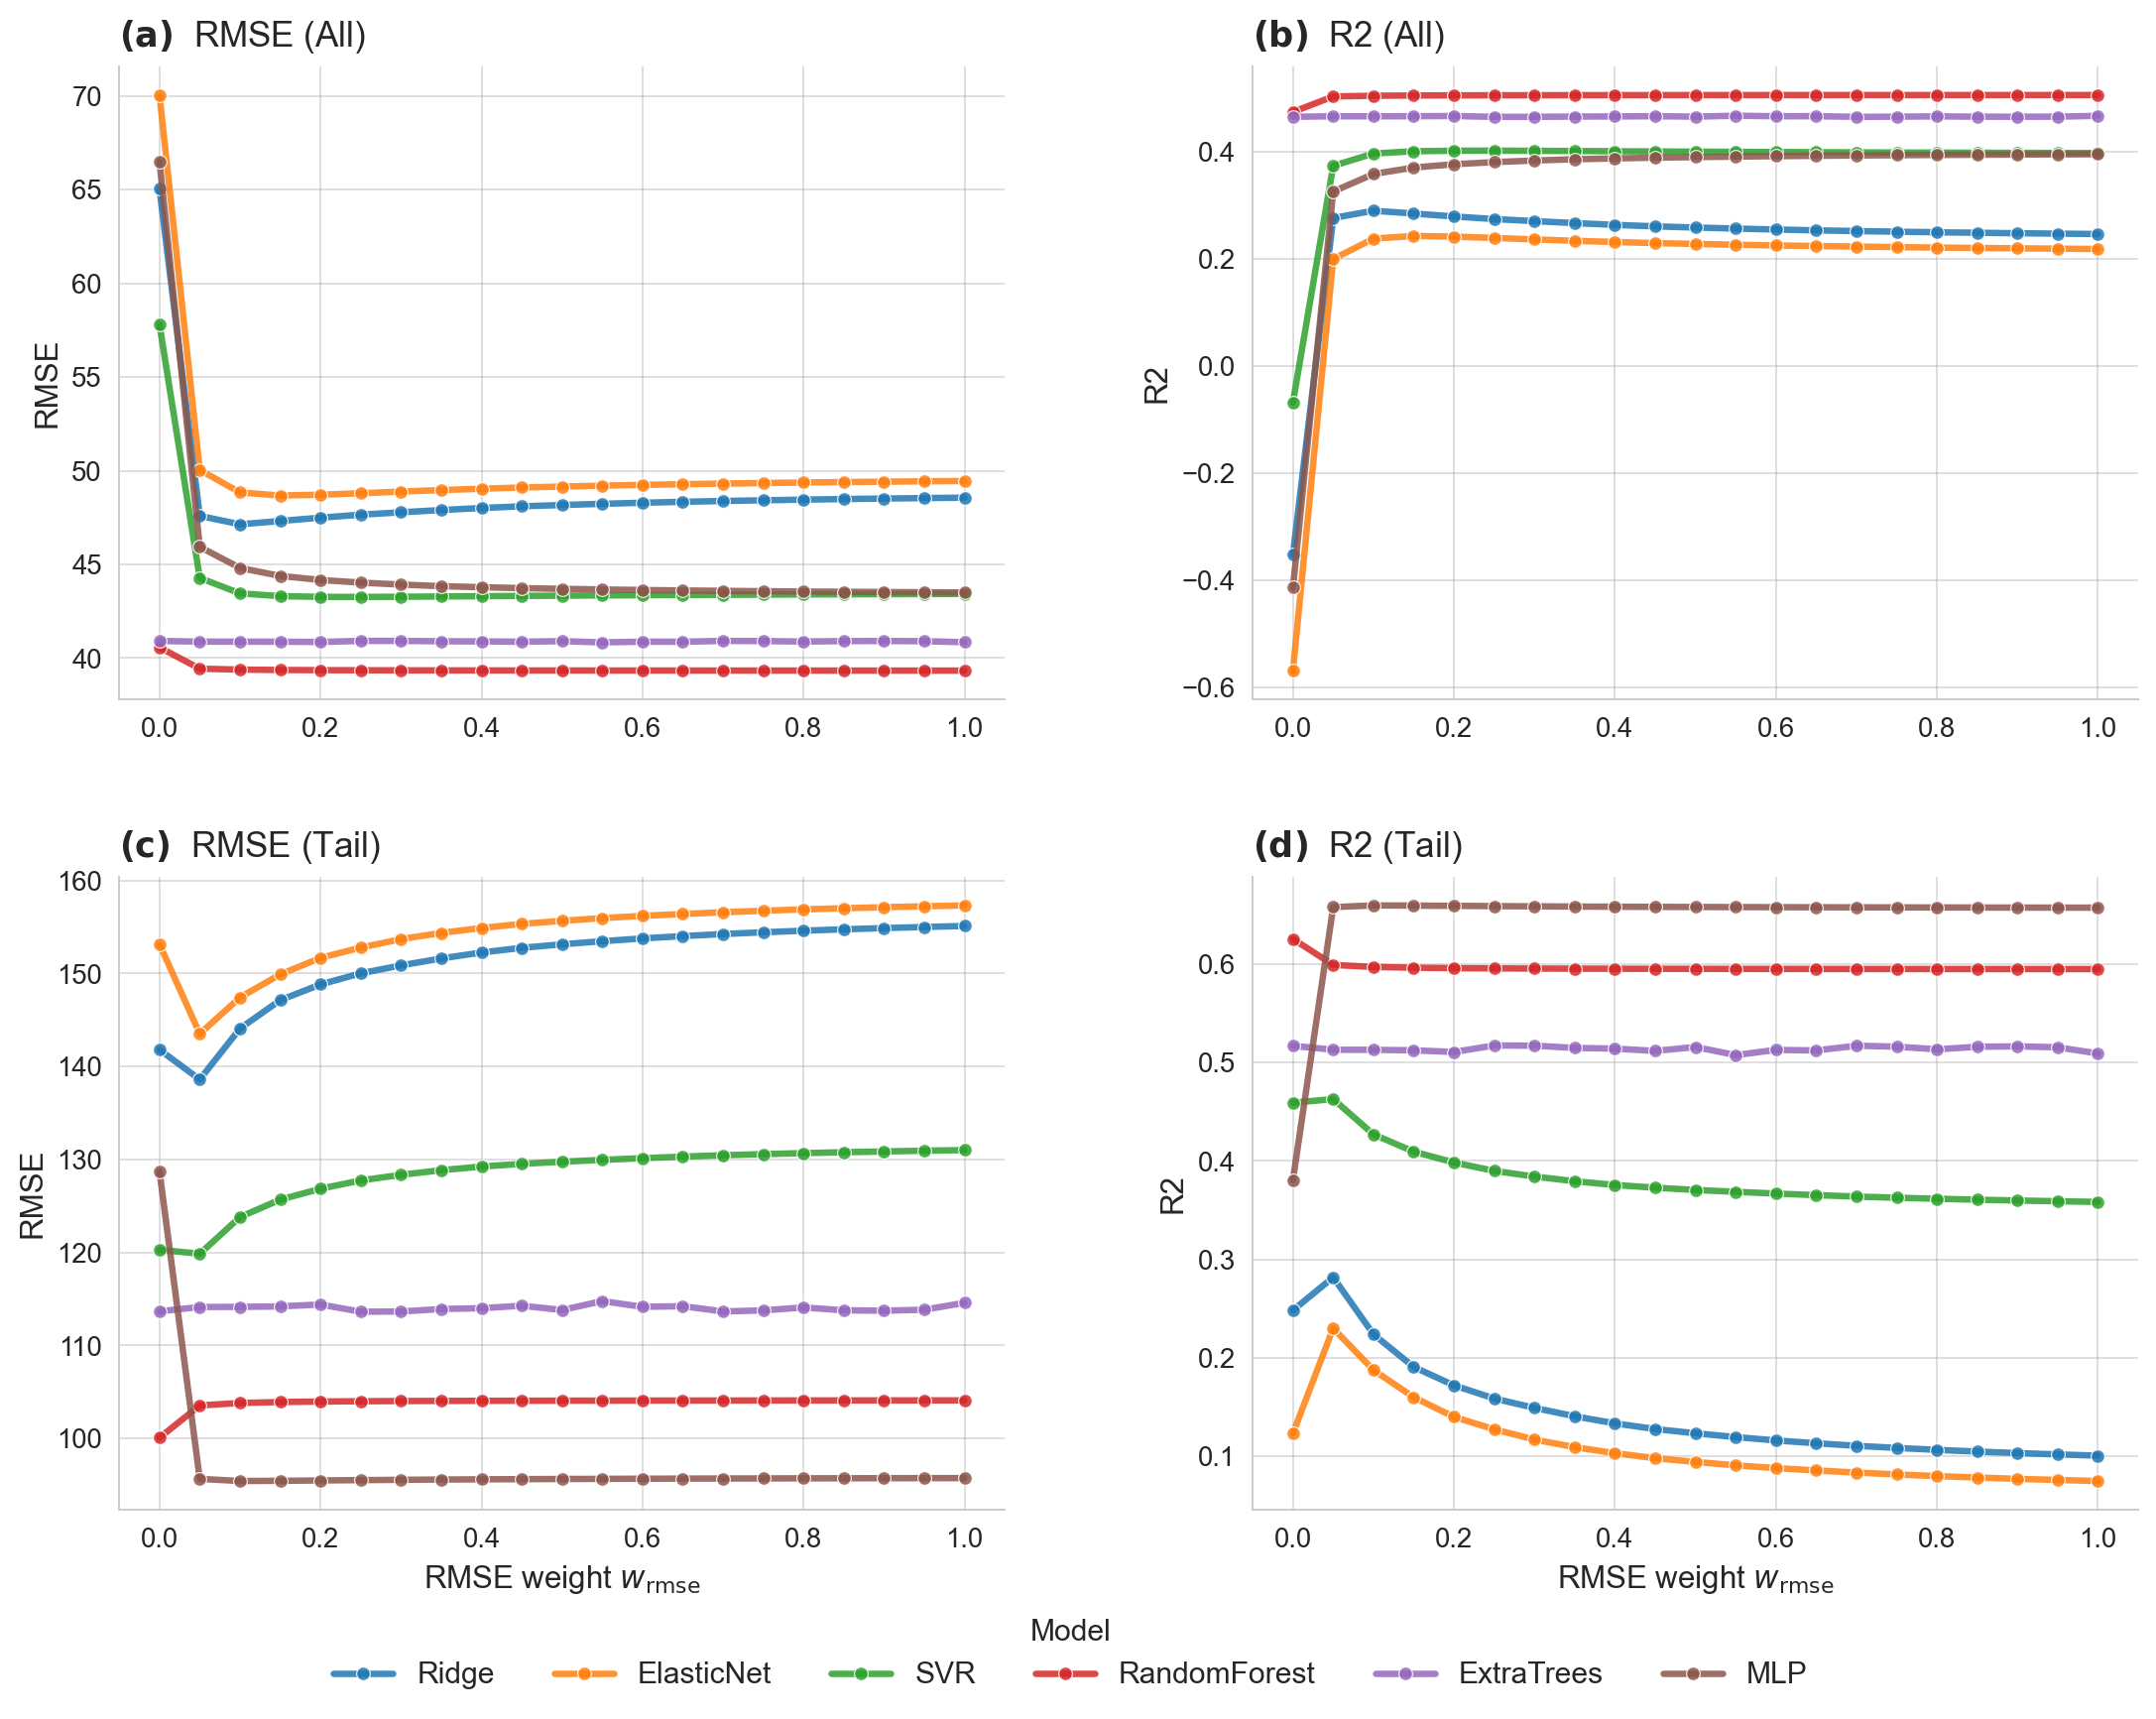

Compound figure saved successfully!


In [46]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set_style("whitegrid", {"grid.alpha": 0.2})
sns.set_palette("husl")

MODEL_ORDER = ["Ridge", "ElasticNet", "SVR", "RandomForest", "ExtraTrees", "MLP"]

# 固定 6 个高区分度颜色
PALETTE6 = {
    "Ridge":       "#1f77b4",  # blue
    "ElasticNet":  "#ff7f0e",  # orange
    "SVR":         "#2ca02c",  # green
    "RandomForest":"#d62728",  # red
    "ExtraTrees":  "#9467bd",  # purple
    "MLP":         "#8c564b",  # brown
}

def plot_metric_per_model_compound(df_raw, split_name, target, save_path=None):
    """
    Create a 2x2 compound figure with:
    - (0,0): RMSE (All)
    - (0,1): R2 (All)
    - (1,0): RMSE (Tail)
    - (1,1): R2 (Tail)
    
    Single shared legend at bottom + panel labels (a, b, c, d).
    """
    d = df_raw[(df_raw["split"] == split_name) & (df_raw["target"] == target)].copy()

    # Create 2x2 subplot layout with enough space for legend
    fig, axes = plt.subplots(2, 2, figsize=(13, 10.5), dpi=180)
    fig.patch.set_facecolor('white')
    
    # Flatten axes for easier iteration
    ax_rmse_all, ax_r2_all = axes[0, :]
    ax_rmse_tail, ax_r2_tail = axes[1, :]
    
    configs = [
        (ax_rmse_all, "RMSE", "All", "(a)"),
        (ax_r2_all,   "R2",   "All", "(b)"),
        (ax_rmse_tail, "RMSE", "Tail", "(c)"),
        (ax_r2_tail,   "R2",   "Tail", "(d)"),
    ]
    
    for ax, metric, data_split, panel_label in configs:
        y_col = f"{metric}_{data_split.lower()}"
        
        for m in MODEL_ORDER:
            dm = d[d["model"] == m].sort_values("w_rmse")
            if dm.empty:
                continue
            
            x = dm["w_rmse"].to_numpy()
            y = dm[y_col].to_numpy()
            c = PALETTE6[m]
            
            ax.plot(x, y, linewidth=2.6, color=c, marker="o", markersize=5.5, 
                    label=m, alpha=0.85, markeredgewidth=0.5, markeredgecolor='white')
        
        # Subplot title with panel label (bold) + metric + split type
        title_text = f"$\\mathbf{{{panel_label}}}$  {metric} ({data_split})"
        ax.set_title(title_text, fontsize=14, loc="left", pad=8, fontweight="normal")
        
        # X-axis: show ticks for all subplots, label only at bottom
        if data_split == "Tail":
            ax.set_xlabel(r"RMSE weight $w_{\rm rmse}$", fontsize=12.5)
        else:
            # Remove label but keep ticks visible
            ax.set_xlabel("")
        
        # Y-axis label
        ax.set_ylabel(metric, fontsize=12.5)
        
        # Tick labels
        ax.tick_params(labelsize=11)
        
        # Grid styling (seaborn whitegrid style)
        ax.grid(True, alpha=0.25, linestyle="-", linewidth=0.8, color="gray")
        ax.set_axisbelow(True)
        
        # Spine styling
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
    
    # # Main title (uncomment to add your own title later)
    # fig.suptitle(
    #     f"{split_name} — {target}",
    #     fontsize=15.5, y=1.01, fontweight="normal"
    # )
    
    # Shared legend at bottom center (outside the subplots)
    # Create legend handles from first subplot
    handles = []
    for m in MODEL_ORDER:
        handles.append(Line2D([0], [0], color=PALETTE6[m], lw=2.6, marker="o", 
                             markersize=5.5, label=m, alpha=0.85, 
                             markeredgewidth=0.5, markeredgecolor='white'))
    
    fig.legend(
        handles=handles, 
        loc="lower center", 
        ncol=6, 
        frameon=False, 
        fontsize=12,
        bbox_to_anchor=(0.5, 0.055),
        title="Model",
        title_fontsize=12
    )
    
    # Adjust layout: reduce inter-subplot spacing, expand overall margins
    fig.subplots_adjust(bottom=0.165, hspace=0.28, wspace=0.28, top=0.935, left=0.09, right=0.96)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=200, facecolor='white', edgecolor='none')

    return fig

# ---- Generate compound figure ----
print("\n" + "="*70)
print("Generating compound figure (2x2 layout with panel labels)")
print("="*70)

fig_compound = plot_metric_per_model_compound(
    df_sweep_raw, split_name, target,
    save_path=os.path.join(_OUTDIR, f"{safe(split_name)}__{safe(target)}__per_model__compound.png"),
)
plt.show()

print("="*70)
print("Compound figure saved successfully!")
print("="*70)


### Notes
- This notebook runs a **Mix-weight sweep** for a chosen *(split, target)* setting.
- It fits each of the **6 baselines once**, then trains an **affine calibrator** for each weight value.
- Curves show **mean ± std across the 6 models** for both **All** and **Tail** metrics.
